# Stage 2 — Local LLM Prompting & Evaluation

**Goal:** Use a local LLM (via [Ollama](https://ollama.ai)) to classify the annotated dataset with zero-shot and few-shot prompts, then evaluate the results rigorously.

We will:
1. Load the annotated dataset from Stage 1
2. Set up the Ollama client (local model, no API key needed)
3. Write and test a **zero-shot** prompt
4. Write and test a **few-shot** prompt
5. Compare both strategies: accuracy, F1, confusion matrix
6. Export evaluation results for Stage 3

**Pre-requisites:**
```bash
# 1. Install Ollama:  https://ollama.ai/download
# 2. Pull a model (we use mistral as a small, capable model):
#    ollama pull mistral
# 3. Start the Ollama server (usually starts automatically after install):
#    ollama serve
```

## 1. Install & import dependencies

In [1]:
# !pip install requests scikit-learn pandas matplotlib seaborn

In [2]:
import json
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

OLLAMA_URL  = 'http://localhost:11434/api/generate'
MODEL_NAME  = 'llama3.1'          # change to llama3, phi3, gemma2, etc.
DATASET_PATH = 'annotated_dataset.jsonl'
LABELS       = ['positive', 'negative', 'neutral']

print(f'Using model: {MODEL_NAME}')

Using model: llama3.1


## 2. Load the annotated dataset

In [3]:
def load_jsonl(path: str) -> list:
    with open(path) as f:
        return [json.loads(line) for line in f]

dataset = load_jsonl(DATASET_PATH)
df_all  = pd.DataFrame(dataset)

# We evaluate only on the test split to keep val unseen until fine-tuning
df_test = df_all[df_all['split'] == 'test'].reset_index(drop=True)
print(f'Test samples: {len(df_test)}')
print(df_test['label'].value_counts().to_string())
df_test[['text', 'label']].head()

Test samples: 5
label
positive    2
neutral     2
negative    1


,text,label
0,Shipping was fast and the packaging was perfect.,positive
1,"Works exactly as described, very happy.",positive
2,Late delivery with zero communication from the...,negative
3,"Average product, nothing special.",neutral
4,Acceptable for the price point.,neutral


## 3. Ollama helper — call local LLM

In [5]:
#temperature is a parameter that controls the randomness, creativity, and "adventurousness" of a model's output, 
#usually set between 0 and 2. A low temperature (<0.5) makes the output more deterministic and focused, 
#while a high temperature (>0.8) makes it more creative and unpredictable


def call_ollama(prompt: str, model: str = MODEL_NAME,
                temperature: float = 0.0) -> str:
    """
    Call the local Ollama server and return the generated text.
    temperature=0 gives deterministic / greedy decoding.
    """
    payload = {
        'model':  model,
        'prompt': prompt,
        'stream': False,
        'options': {'temperature': temperature},
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=60)
        resp.raise_for_status()
        return resp.json()['response'].strip()
    except requests.exceptions.ConnectionError:
        raise RuntimeError(
            'Cannot reach Ollama. Is the server running?\n'
            'Run: ollama serve'
        )

# Smoke test
reply = call_ollama('Reply with the single word: ready')
print(f'Smoke test response: "{reply}"')

Smoke test response: "Ready"


## 4. Label extractor — parse raw model output

In [7]:
#an extractor so we can return the output in a single format

def extract_label(raw_output: str, valid_labels: list = LABELS) -> str:
    """
    Find the first valid label word in the model's output.
    Returns 'unknown' if none is found.
    """
    text = raw_output.lower().strip()
    for label in valid_labels:
        if label in text:
            return label
    return 'unknown'

# Test the extractor
assert extract_label('The sentiment is POSITIVE.') == 'positive'
assert extract_label('neutral')                    == 'neutral'
assert extract_label('I cannot determine.')        == 'unknown'
print('Label extractor OK.')

Label extractor OK.


## 5. Prompt templates

### 5a. Zero-shot prompt

No examples — relies entirely on the model's pre-trained knowledge.

In [8]:
def zero_shot_prompt(text: str) -> str:
    return f"""You are a sentiment classifier.
Classify the sentiment of the following customer review.
Reply with EXACTLY one word: positive, negative, or neutral.

Review: {text}

Sentiment:"""

# Preview
sample = df_test.iloc[0]['text']
print('--- PROMPT ---')
print(zero_shot_prompt(sample))
print('--- RAW OUTPUT ---')
raw = call_ollama(zero_shot_prompt(sample))
print(raw)
print('--- EXTRACTED LABEL ---')
print(extract_label(raw))

--- PROMPT ---
You are a sentiment classifier.
Classify the sentiment of the following customer review.
Reply with EXACTLY one word: positive, negative, or neutral.

Review: Shipping was fast and the packaging was perfect.

Sentiment:
--- RAW OUTPUT ---
Positive.
--- EXTRACTED LABEL ---
positive


### 5b. Few-shot prompt

Three labelled examples (one per class) anchor the model to our specific label schema.

In [9]:
FEW_SHOT_EXAMPLES = [
    ('Best purchase I have made this year.',       'positive'),
    ('Product arrived damaged and no one replied.', 'negative'),
    ('It does what it says on the box.',            'neutral'),
]

def few_shot_prompt(text: str, examples: list = FEW_SHOT_EXAMPLES) -> str:
    ex_block = '\n'.join(
        f'Review: {t}\nSentiment: {l}' for t, l in examples
    )
    return f"""You are a sentiment classifier.
Classify the sentiment of a customer review.
Reply with EXACTLY one word: positive, negative, or neutral.

Examples:
{ex_block}

Review: {text}
Sentiment:"""

# Preview
print('--- FEW-SHOT PROMPT ---')
print(few_shot_prompt(sample))
print('--- RAW OUTPUT ---')
raw = call_ollama(few_shot_prompt(sample))
print(raw)
print('--- EXTRACTED LABEL ---')
print(extract_label(raw))

--- FEW-SHOT PROMPT ---
You are a sentiment classifier.
Classify the sentiment of a customer review.
Reply with EXACTLY one word: positive, negative, or neutral.

Examples:
Review: Best purchase I have made this year.
Sentiment: positive
Review: Product arrived damaged and no one replied.
Sentiment: negative
Review: It does what it says on the box.
Sentiment: neutral

Review: Shipping was fast and the packaging was perfect.
Sentiment:
--- RAW OUTPUT ---
positive
--- EXTRACTED LABEL ---
positive


## 6. Run evaluation on the test set

⏱️ This cell calls the model for every test sample — expect ~1–3 s per call depending on hardware.

In [10]:
def evaluate_prompt_strategy(
    df: pd.DataFrame,
    prompt_fn,
    strategy_name: str
) -> pd.DataFrame:
    """
    Apply prompt_fn to every row in df and return a copy with
    columns: raw_output, predicted_label.
    """
    results = df.copy()
    raws, preds = [], []

    for i, row in df.iterrows():
        prompt = prompt_fn(row['text'])
        raw    = call_ollama(prompt)
        pred   = extract_label(raw)
        raws.append(raw)
        preds.append(pred)
        print(f'  [{strategy_name}] {i+1}/{len(df)}  gold={row["label"]}  pred={pred}')
        time.sleep(0.1)   # small pause — not strictly needed locally

    results['raw_output']       = raws
    results['predicted_label']  = preds
    results['strategy']         = strategy_name
    return results

print('Running zero-shot evaluation...')
df_zero = evaluate_prompt_strategy(df_test, zero_shot_prompt, 'zero_shot')

print('\nRunning few-shot evaluation...')
df_few  = evaluate_prompt_strategy(df_test, few_shot_prompt,  'few_shot')

Running zero-shot evaluation...
  [zero_shot] 1/5  gold=positive  pred=positive
  [zero_shot] 2/5  gold=positive  pred=positive
  [zero_shot] 3/5  gold=negative  pred=negative
  [zero_shot] 4/5  gold=neutral  pred=neutral
  [zero_shot] 5/5  gold=neutral  pred=neutral

Running few-shot evaluation...
  [few_shot] 1/5  gold=positive  pred=positive
  [few_shot] 2/5  gold=positive  pred=positive
  [few_shot] 3/5  gold=negative  pred=negative
  [few_shot] 4/5  gold=neutral  pred=neutral
  [few_shot] 5/5  gold=neutral  pred=neutral


## 7. Metrics

In [11]:
def compute_metrics(df_results: pd.DataFrame, strategy: str) -> dict:
    y_true = df_results['label'].tolist()
    y_pred = df_results['predicted_label'].tolist()

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro',
                   labels=LABELS, zero_division=0)

    unknown_rate = y_pred.count('unknown') / len(y_pred)

    print(f'\n=== {strategy.upper()} ===')
    print(f'Accuracy:      {acc:.3f}')
    print(f'Macro F1:      {f1:.3f}')
    print(f'Unknown rate:  {unknown_rate:.1%}')
    print('\nDetailed report:')
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

    return {'strategy': strategy, 'accuracy': acc, 'macro_f1': f1,
            'unknown_rate': unknown_rate}

m_zero = compute_metrics(df_zero, 'zero_shot')
m_few  = compute_metrics(df_few,  'few_shot')

metrics_df = pd.DataFrame([m_zero, m_few])
metrics_df


=== ZERO_SHOT ===
Accuracy:      1.000
Macro F1:      1.000
Unknown rate:  0.0%

Detailed report:
              precision    recall  f1-score   support

    positive       1.00      1.00      1.00         2
    negative       1.00      1.00      1.00         1
     neutral       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


=== FEW_SHOT ===
Accuracy:      1.000
Macro F1:      1.000
Unknown rate:  0.0%

Detailed report:
              precision    recall  f1-score   support

    positive       1.00      1.00      1.00         2
    negative       1.00      1.00      1.00         1
     neutral       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



,strategy,accuracy,macro_f1,unknown_rate
0,zero_shot,1.0,1.0,0.0
1,few_shot,1.0,1.0,0.0


## 8. Confusion matrices

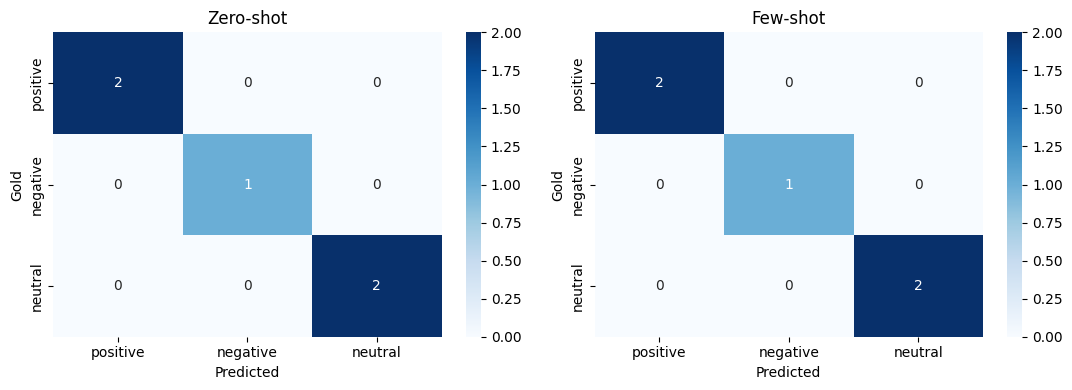

Saved → confusion_matrices.png


In [12]:
def plot_cm(df_results: pd.DataFrame, title: str, ax):
    y_true = df_results['label']
    y_pred = df_results['predicted_label']
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Gold')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cm(df_zero, 'Zero-shot', axes[0])
plot_cm(df_few,  'Few-shot',  axes[1])
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print('Saved → confusion_matrices.png')

## 9. Error analysis — where does the model fail?

In [13]:
errors = df_few[df_few['label'] != df_few['predicted_label']].copy()
print(f'Few-shot errors: {len(errors)}')
errors[['text', 'label', 'predicted_label', 'raw_output']]

Few-shot errors: 0


,text,label,predicted_label,raw_output


## 10. Export evaluation results

In [14]:
# Save per-sample predictions
combined = pd.concat([df_zero, df_few], ignore_index=True)
combined.to_csv('evaluation_results_stage2.csv', index=False)
print('Saved → evaluation_results_stage2.csv')

# Save summary metrics
metrics_df.to_csv('metrics_summary_stage2.csv', index=False)
print('Saved → metrics_summary_stage2.csv')

# Summary
print('\n--- Baseline to beat in Stage 3 (fine-tuning) ---')
best = metrics_df.loc[metrics_df['macro_f1'].idxmax()]
print(f"Best strategy : {best['strategy']}")
print(f"Accuracy      : {best['accuracy']:.3f}")
print(f"Macro F1      : {best['macro_f1']:.3f}")

Saved → evaluation_results_stage2.csv
Saved → metrics_summary_stage2.csv

--- Baseline to beat in Stage 3 (fine-tuning) ---
Best strategy : zero_shot
Accuracy      : 1.000
Macro F1      : 1.000


## ✅ Stage 2 complete

Outputs produced:
- `evaluation_results_stage2.csv` — per-sample predictions for both strategies
- `metrics_summary_stage2.csv` — accuracy / F1 / unknown-rate summary
- `confusion_matrices.png` — visual comparison

Take the **best macro F1** as the baseline. Stage 3 (fine-tuning) will try to beat it.